In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# For reading stock data from yahoo
from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr

from datetime import datetime
end = datetime.now()

import yfinance as yf

data = yf.download("MRF.NS", start="2014-07-01", end=end)
print(data.head())
import warnings
warnings.filterwarnings('ignore')

[*********************100%***********************]  1 of 1 completed

                    Open          High           Low         Close  \
Date                                                                 
2014-07-01  23699.800781  23775.000000  23500.000000  23649.750000   
2014-07-02  23750.000000  24034.500000  23658.849609  23866.050781   
2014-07-03  23875.000000  24049.000000  23550.000000  23732.400391   
2014-07-04  23970.000000  23970.000000  23572.599609  23742.449219   
2014-07-07  23750.000000  23859.949219  23540.000000  23620.849609   

               Adj Close  Volume  
Date                              
2014-07-01  23295.550781    2941  
2014-07-02  23508.609375    8725  
2014-07-03  23376.957031    3469  
2014-07-04  23386.855469    3614  
2014-07-07  23267.078125    2195  


In [2]:
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-07-01,23699.800781,23775.000000,23500.000000,23649.750000,23295.550781,2941
2014-07-02,23750.000000,24034.500000,23658.849609,23866.050781,23508.609375,8725
2014-07-03,23875.000000,24049.000000,23550.000000,23732.400391,23376.957031,3469
2014-07-04,23970.000000,23970.000000,23572.599609,23742.449219,23386.855469,3614
2014-07-07,23750.000000,23859.949219,23540.000000,23620.849609,23267.078125,2195
...,...,...,...,...,...,...
2024-08-27,139360.000000,139849.953125,138448.906250,138807.593750,138807.593750,4576
2024-08-28,139500.000000,139500.000000,136486.343750,136856.296875,136856.296875,6441
2024-08-29,137000.000000,137312.843750,133390.000000,134421.093750,134421.093750,10344


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2506 entries, 2014-07-01 to 2024-09-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2506 non-null   float64
 1   High       2506 non-null   float64
 2   Low        2506 non-null   float64
 3   Close      2506 non-null   float64
 4   Adj Close  2506 non-null   float64
 5   Volume     2506 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 137.0 KB


In [4]:
type(data)

pandas.core.frame.DataFrame

In [5]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2506.000000,2506.000000,2506.000000,2506.000000,2506.000000,2506.000000
mean,68996.890110,69743.272428,68183.774526,68916.782931,68467.996475,11934.112530
std,26633.840723,26844.226117,26374.561179,26597.689766,26686.284516,12929.032064
min,21617.099609,21899.000000,21001.000000,21513.900391,21191.685547,0.000000
25%,51999.250000,52662.236328,51292.298828,51975.737305,51443.603516,5417.500000
50%,66793.949219,67498.898438,65909.500000,66713.898438,66193.792969,8381.000000
75%,81007.500000,81886.386719,80100.000000,80863.828125,80453.115234,13561.250000
max,150850.000000,151445.000000,150050.000000,150725.000000,150511.984375,281075.000000


In [6]:
data.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

### EDA

<Axes: xlabel='Date'>

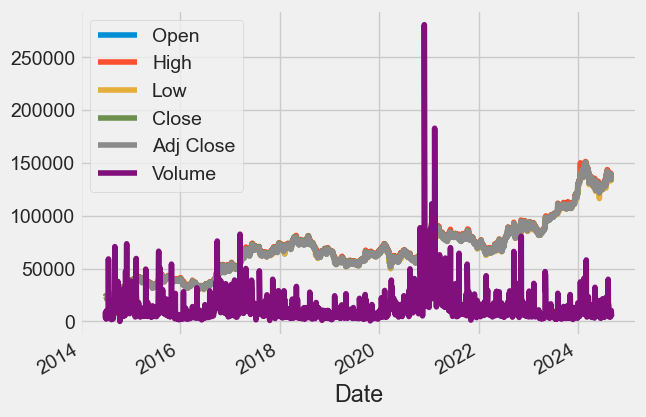

In [7]:
data.plot()

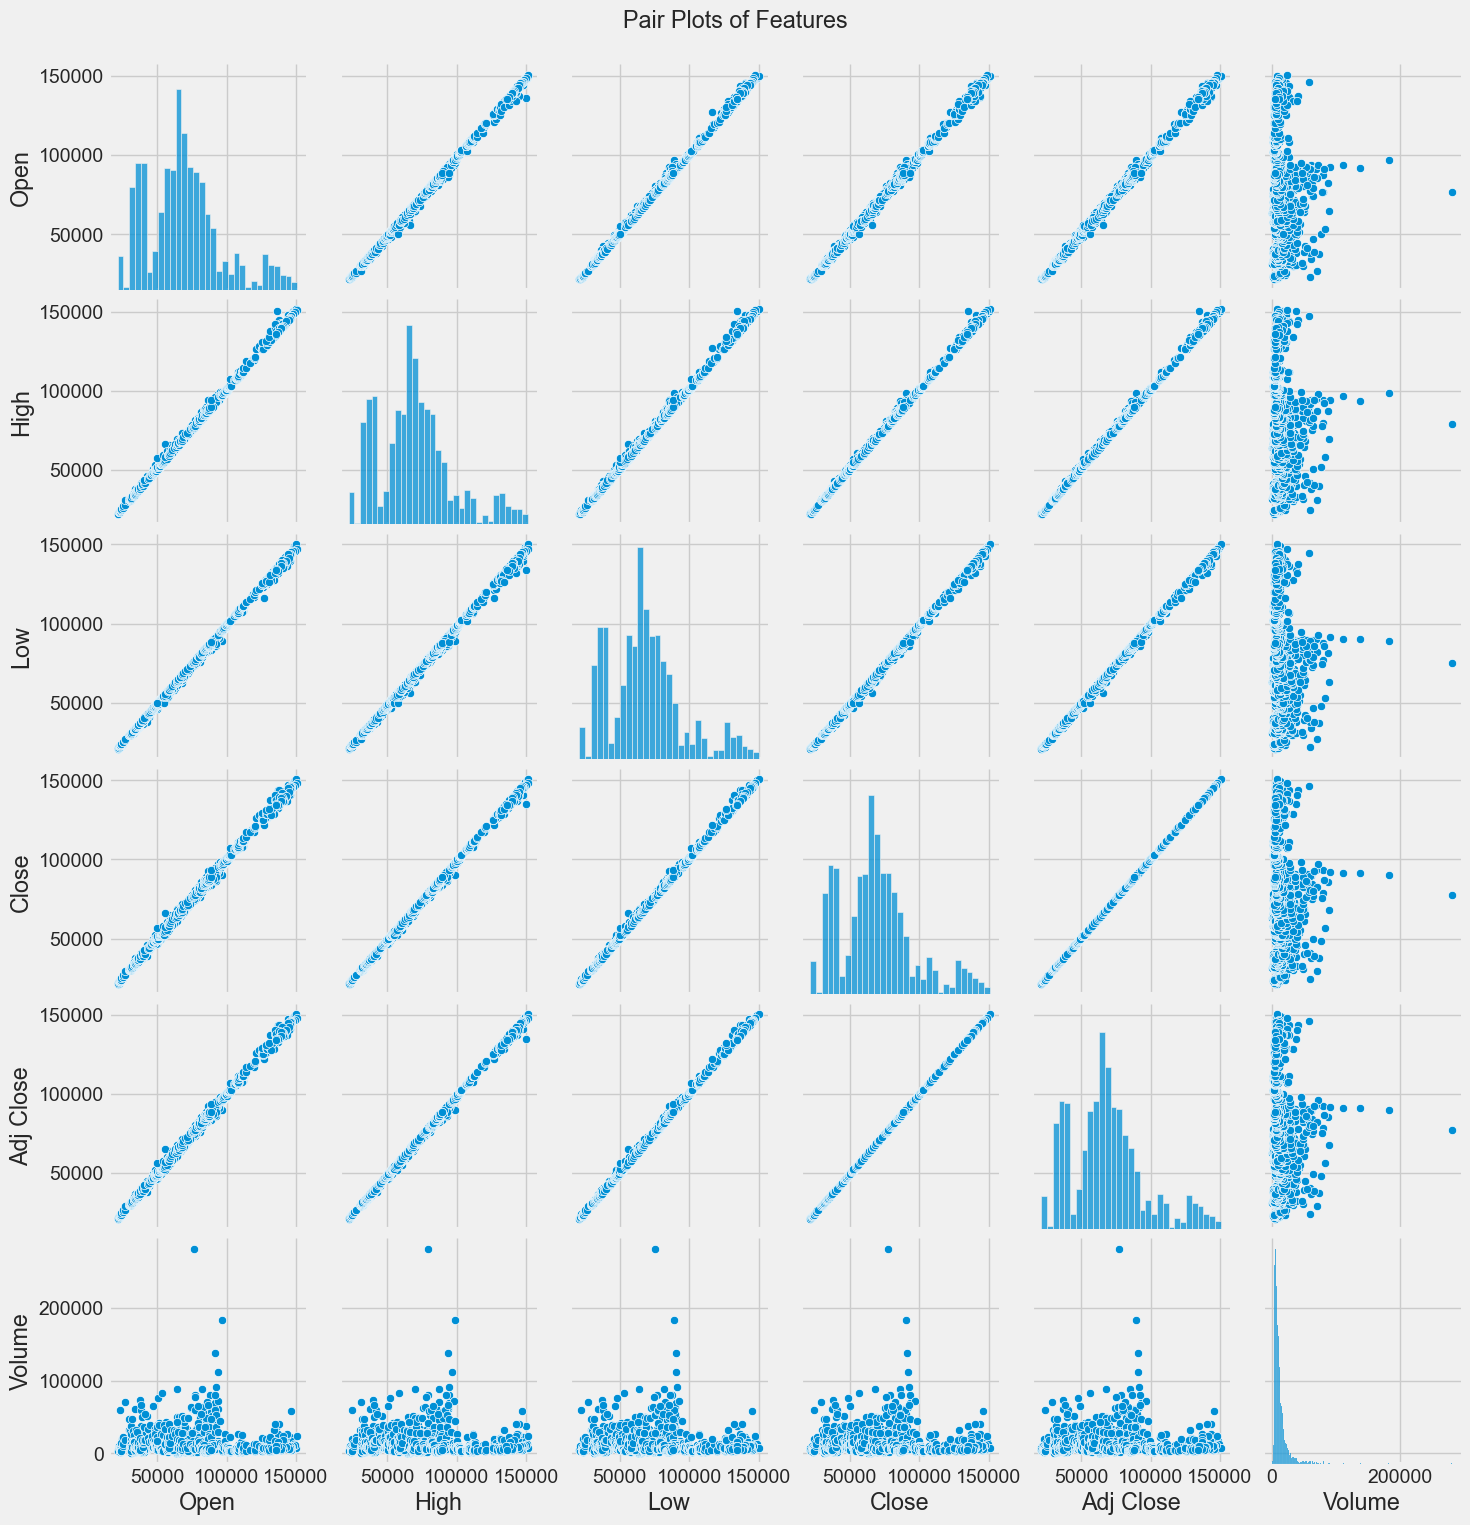

In [8]:
#Pair Plots
sns.pairplot(data[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']])
plt.suptitle('Pair Plots of Features', y=1.02)
plt.show()

### Closing Price

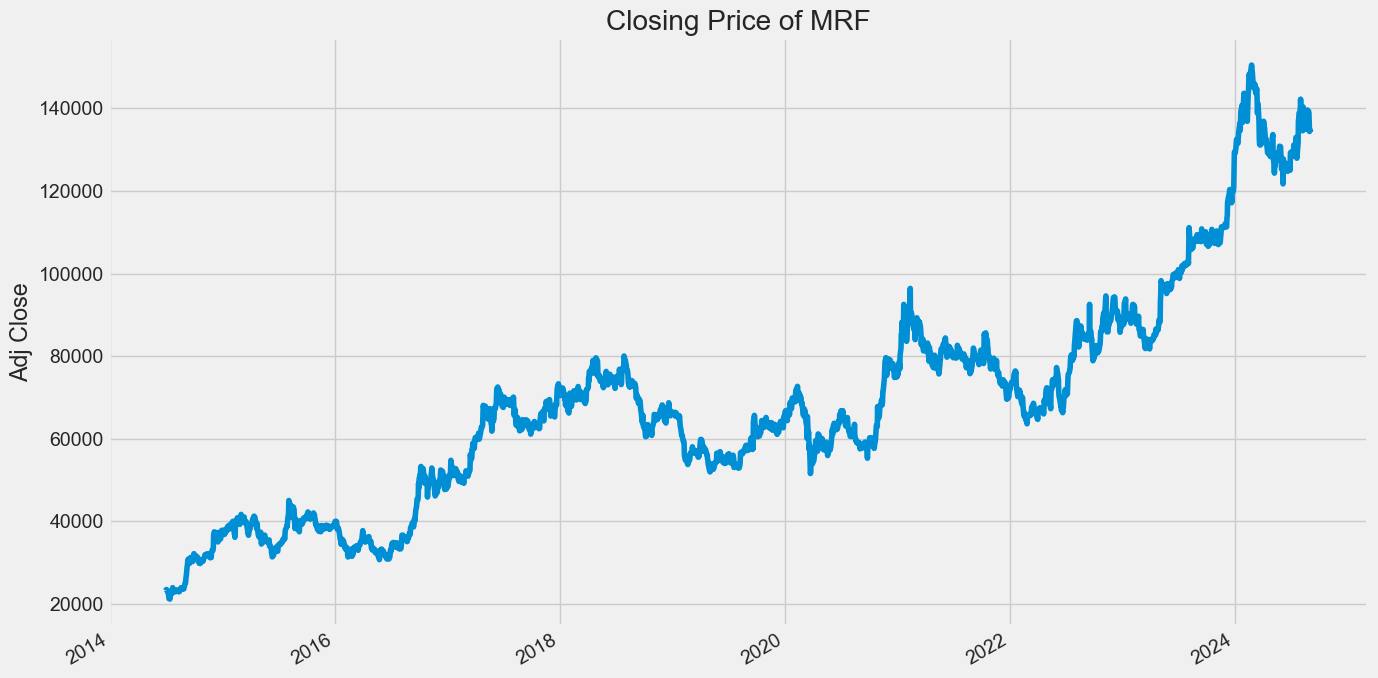

In [9]:
# Let's see a historical view of the closing price
plt.figure(figsize=(14, 7))
data['Adj Close'].plot()
plt.ylabel('Adj Close')
plt.xlabel(None)
plt.title(f"Closing Price of MRF")
    
plt.tight_layout()

### Volume of Sales

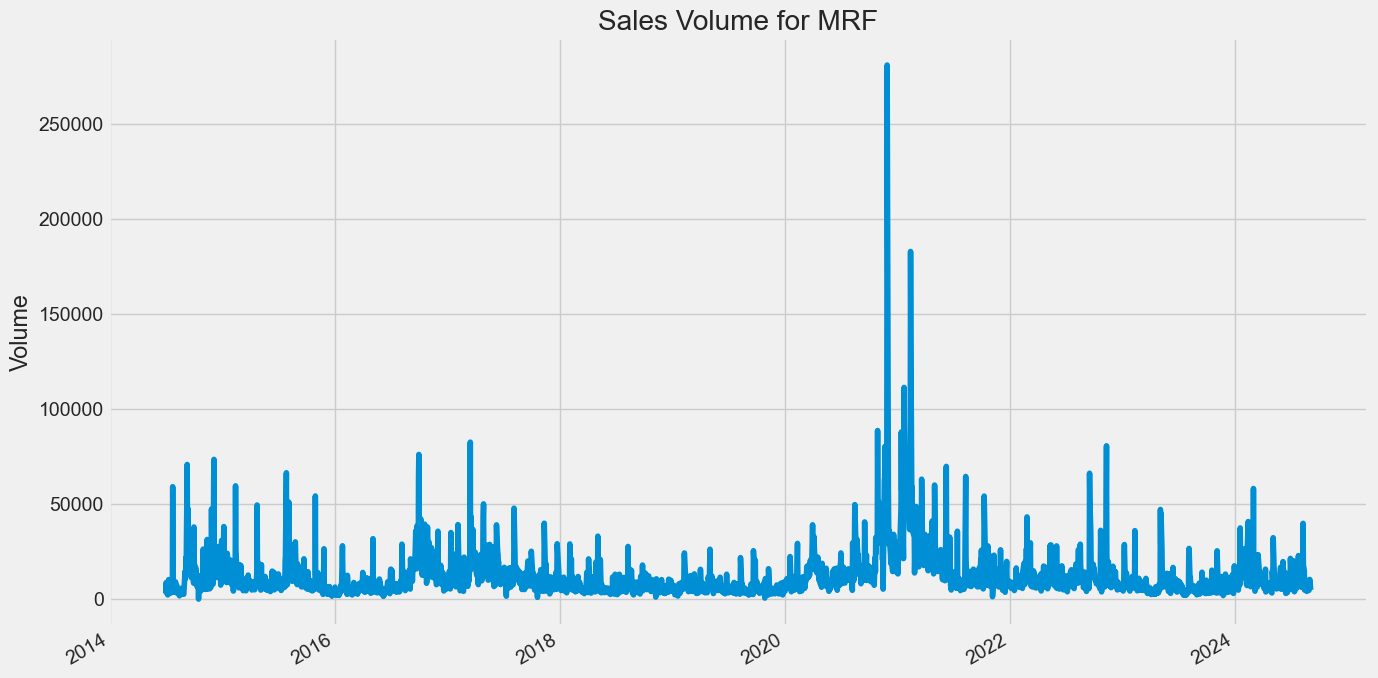

In [10]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(14, 7))
data['Volume'].plot()
plt.ylabel('Volume')
plt.xlabel(None)
plt.title(f"Sales Volume for MRF")
    
plt.tight_layout()

### Moving Average of MRF

In [11]:
#Rolling Averages
data['7_day_MA'] = data['Close'].rolling(window=7).mean()
data['30_day_MA'] = data['Close'].rolling(window=30).mean()

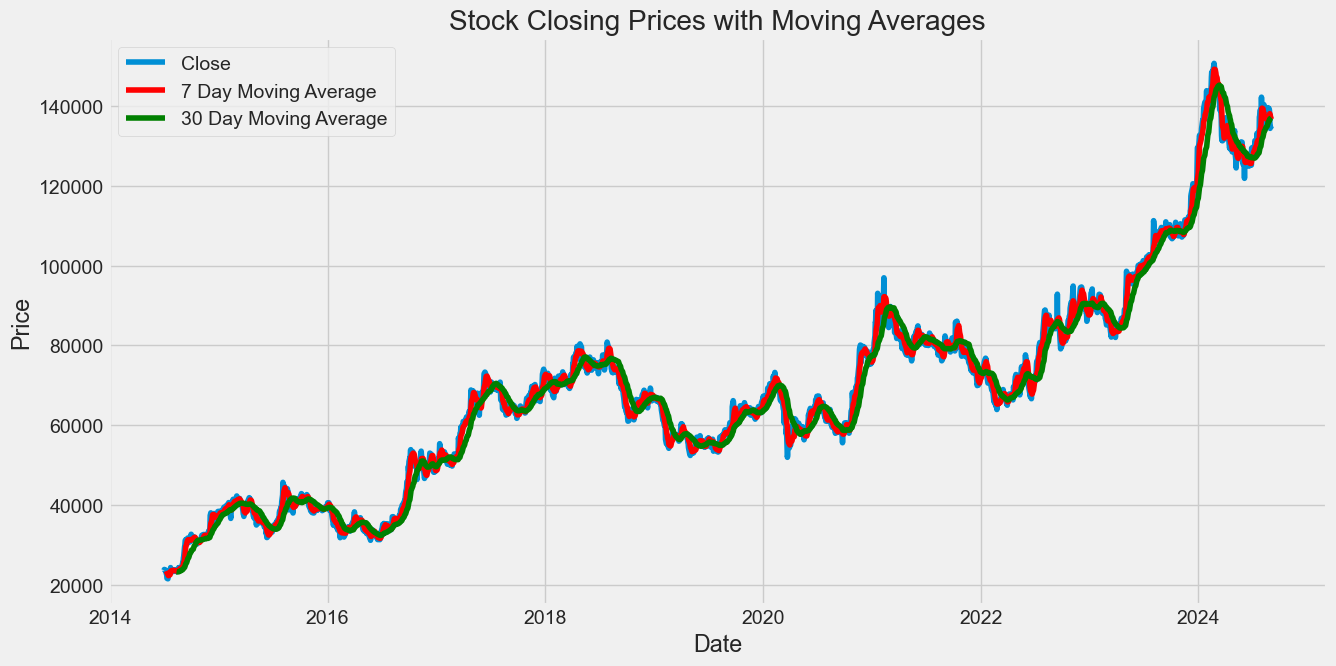

In [12]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close')
plt.plot(data['7_day_MA'], label='7 Day Moving Average', color='red')
plt.plot(data['30_day_MA'], label='30 Day Moving Average', color='green')
plt.title('Stock Closing Prices with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

### Daily return of the stock on average

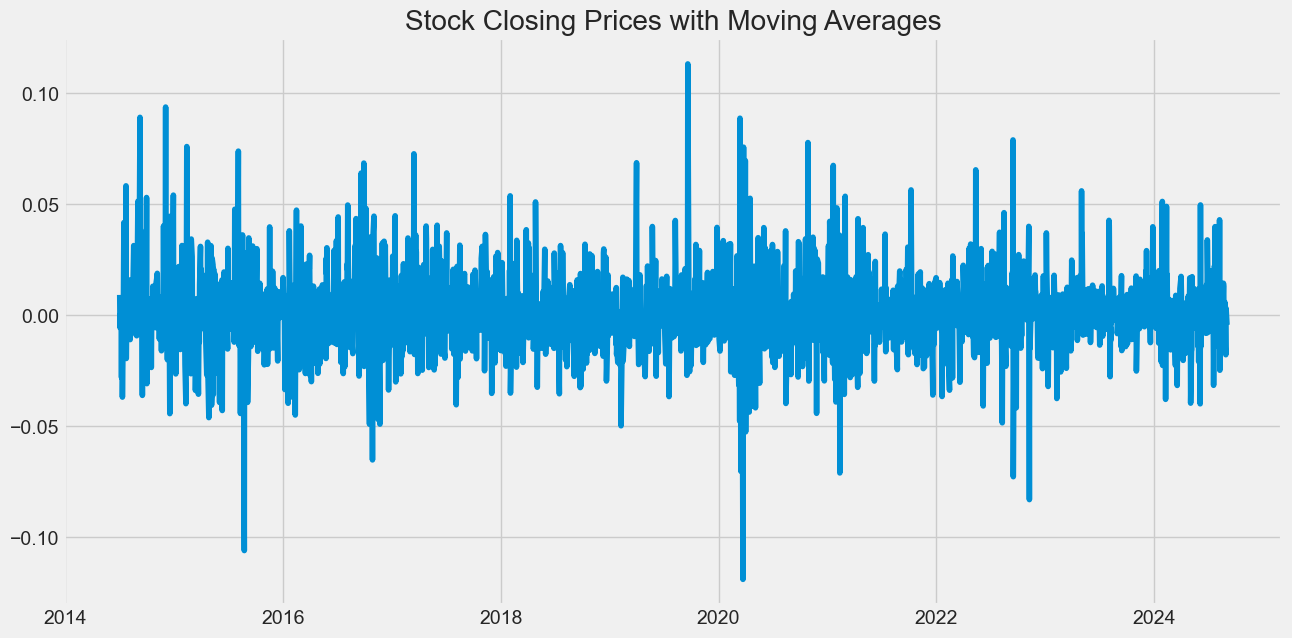

In [13]:
# We'll use pct_change to find the percent change for each day

data['Daily Return'] = data['Adj Close'].pct_change()

plt.figure(figsize=(14, 7))
plt.plot(data['Daily Return'])
plt.title('Stock Closing Prices with Moving Averages')
plt.show()

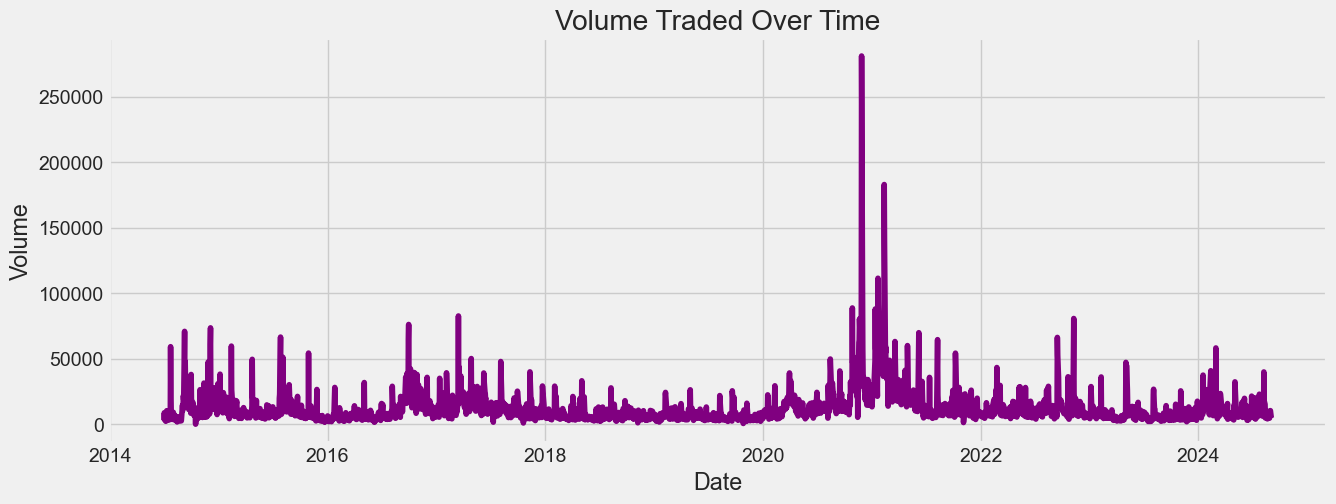

In [14]:
# Volume trends over time
plt.figure(figsize=(14, 5))
plt.plot(data['Volume'], color='purple')
plt.title('Volume Traded Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

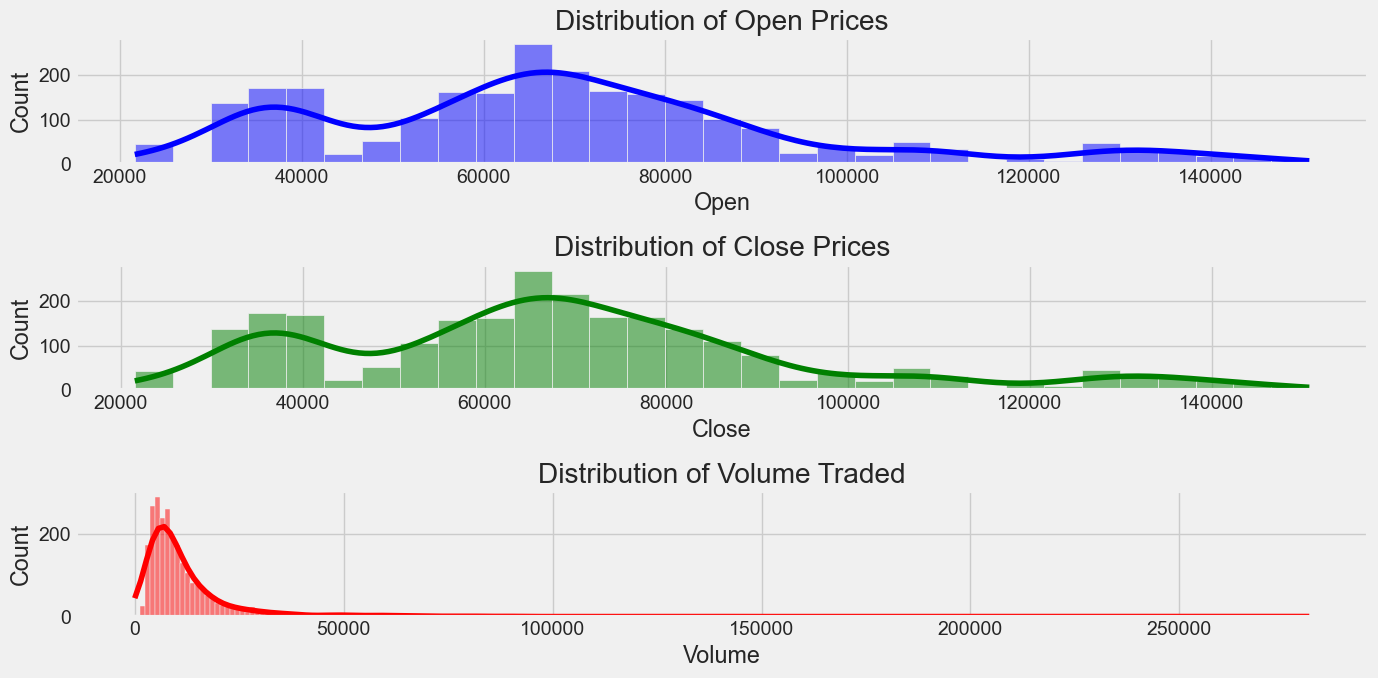

In [15]:
#Distribution Plots
plt.figure(figsize=(14, 7))

plt.subplot(3, 1, 1)
sns.histplot(data['Open'], kde=True, color='blue')
plt.title('Distribution of Open Prices')

plt.subplot(3, 1, 2)
sns.histplot(data['Close'], kde=True, color='green')
plt.title('Distribution of Close Prices')

plt.subplot(3, 1, 3)
sns.histplot(data['Volume'], kde=True, color='red')
plt.title('Distribution of Volume Traded')

plt.tight_layout()
plt.show()

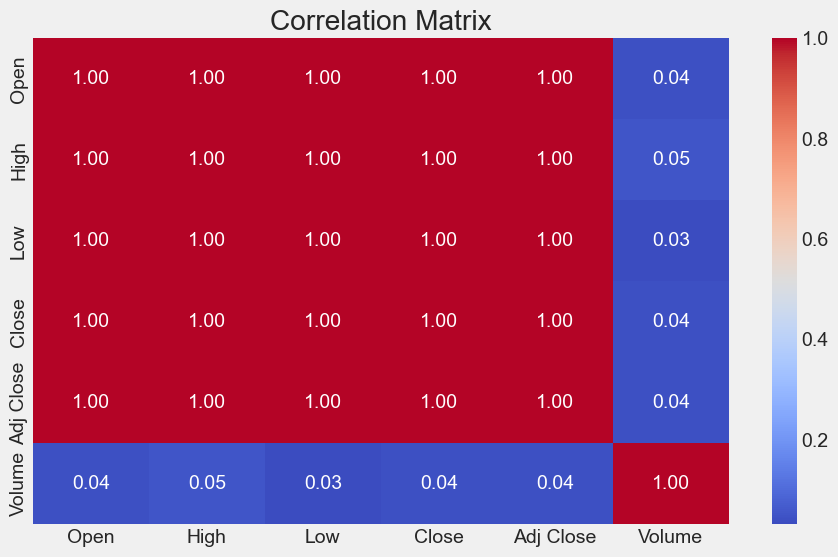

In [16]:
#Correlation Analysis
correlation_matrix = data[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

<Figure size 1400x1000 with 0 Axes>

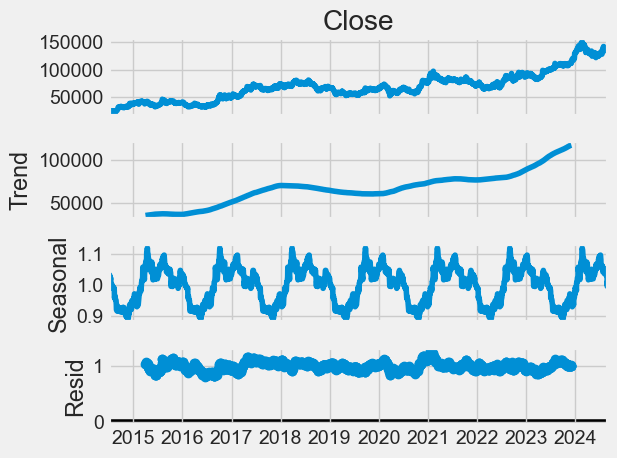

In [17]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decompose_result = seasonal_decompose(data['Close'], model='multiplicative', period=365)

plt.figure(figsize=(14, 10))
decompose_result.plot()
plt.show()

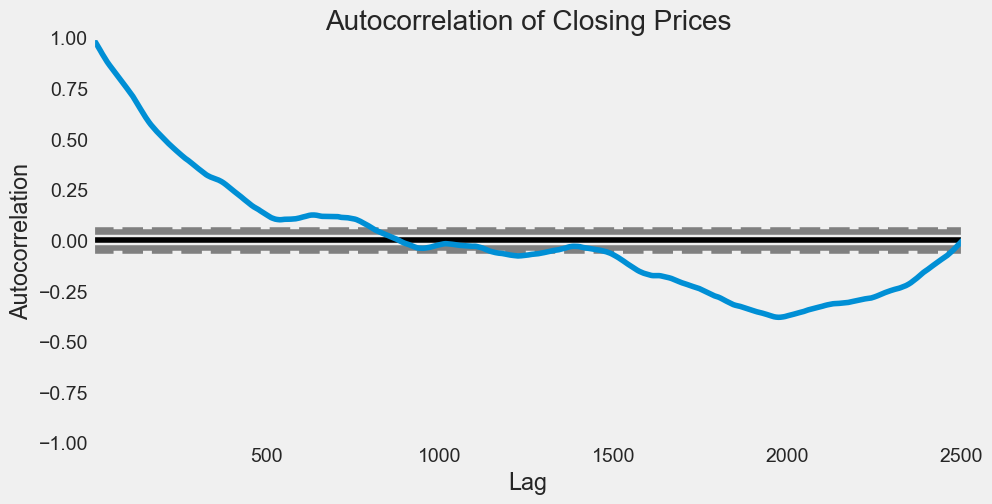

In [18]:
# Autocorrelation Plot
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(10, 5))
autocorrelation_plot(data['Close'])
plt.title('Autocorrelation of Closing Prices')
plt.show()

In [19]:
# Grab all the closing prices for the tech stock list into one DataFrame

closing_df = data['Adj Close']

# Make a new tech returns DataFrame
mrf_rets = closing_df.pct_change()
mrf_rets.head()

Date
2014-07-01         NaN
2014-07-02    0.009146
2014-07-03   -0.005600
2014-07-04    0.000423
2014-07-07   -0.005122
Name: Adj Close, dtype: float64

### How much value do we put at risk by investing in a MRF stock?

In [20]:
rets = mrf_rets.dropna()
rets

Date
2014-07-02    0.009146
2014-07-03   -0.005600
2014-07-04    0.000423
2014-07-07   -0.005122
2014-07-08   -0.028072
                ...   
2024-08-27   -0.003710
2024-08-28   -0.014058
2024-08-29   -0.017794
2024-08-30    0.003068
2024-09-02   -0.004328
Name: Adj Close, Length: 2505, dtype: float64

Text(2, 1, 'MRF')

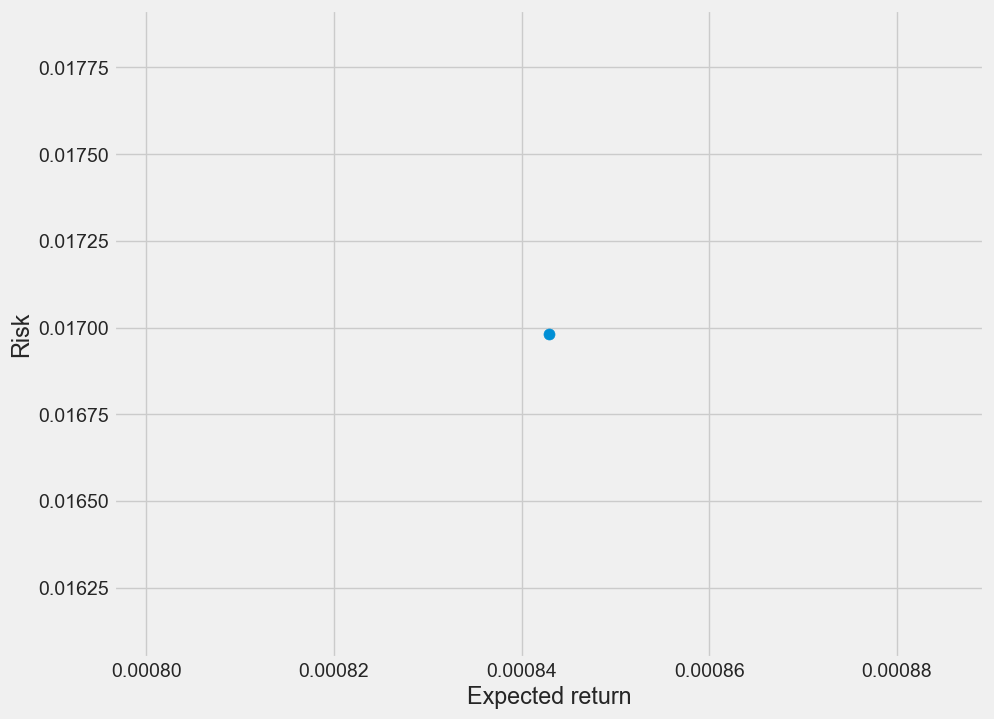

In [21]:
area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

plt.annotate('MRF', xy=(2, 1), textcoords='offset points', ha='right', va='bottom', arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

### Predicting the closing price stock price of MRF:

### LSTM

In [22]:
# Get the stock quote
df = yf.download("MRF.NS", start="2014-07-01", end=end)
# Show teh data
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-07-01,23699.800781,23775.000000,23500.000000,23649.750000,23295.550781,2941
2014-07-02,23750.000000,24034.500000,23658.849609,23866.050781,23508.609375,8725
2014-07-03,23875.000000,24049.000000,23550.000000,23732.400391,23376.957031,3469
2014-07-04,23970.000000,23970.000000,23572.599609,23742.449219,23386.855469,3614
2014-07-07,23750.000000,23859.949219,23540.000000,23620.849609,23267.078125,2195
...,...,...,...,...,...,...
2024-08-27,139360.000000,139849.953125,138448.906250,138807.593750,138807.593750,4576
2024-08-28,139500.000000,139500.000000,136486.343750,136856.296875,136856.296875,6441
2024-08-29,137000.000000,137312.843750,133390.000000,134421.093750,134421.093750,10344


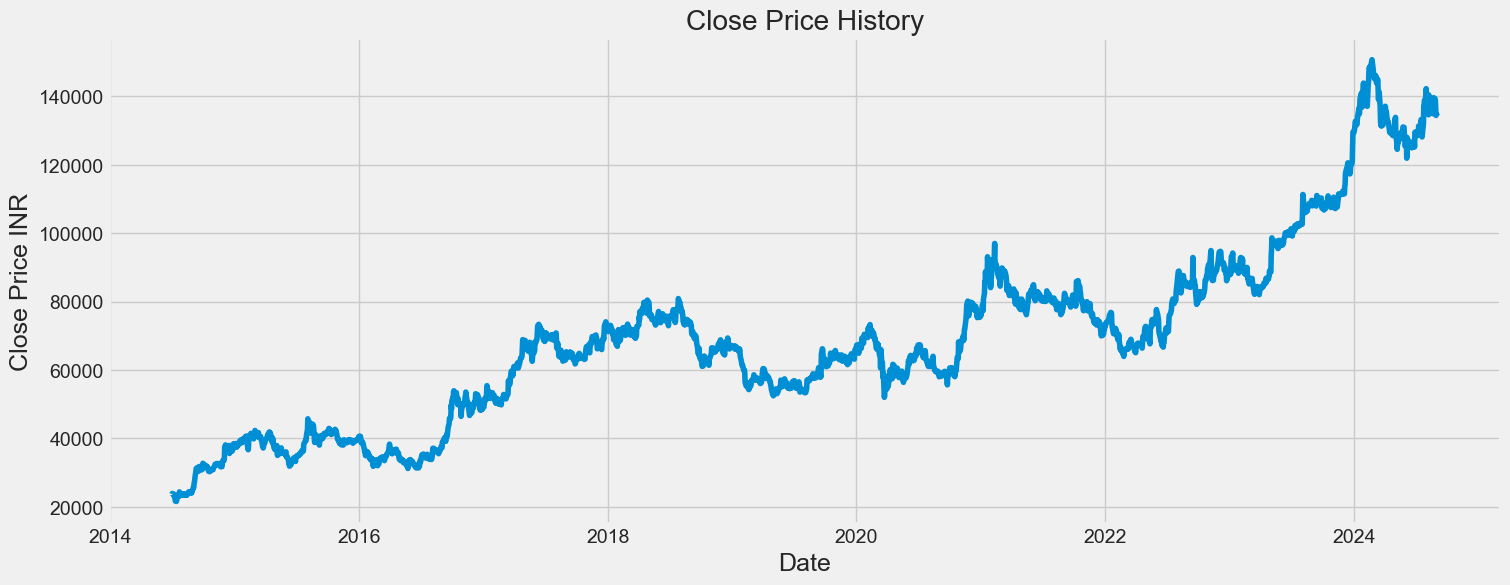

In [23]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR', fontsize=18)
plt.show()

In [24]:
# Create a new dataframe with only the 'Close column 
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

2381

In [25]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.01652992],
       [0.01820393],
       [0.01716958],
       ...,
       [0.87381962],
       [0.87701098],
       [0.87249511]])

In [26]:
# Create the training data set 
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.01652992, 0.01820393, 0.01716958, 0.01724735, 0.01630626,
       0.01117435, 0.01021351, 0.00720643, 0.00079869, 0.        ,
       0.00304037, 0.01011833, 0.0137345 , 0.01391328, 0.01314089,
       0.01143981, 0.02181237, 0.0181424 , 0.01707128, 0.01610194,
       0.0160261 , 0.01411101, 0.01401002, 0.01687665, 0.01760298,
       0.01555864, 0.0160292 , 0.01486288, 0.01428901, 0.01459588,
       0.01405259, 0.01432577, 0.01999866, 0.02168274, 0.0205083 ,
       0.02090338, 0.02175703, 0.02011437, 0.01960668, 0.02121722,
       0.01948013, 0.02902421, 0.03167878, 0.03166601, 0.04030033,
       0.04369438, 0.06243116, 0.06496113, 0.07387059, 0.07543083,
       0.07484651, 0.07671825, 0.06793611, 0.07579147, 0.07746857,
       0.07920836, 0.07806875, 0.07323868, 0.07605151, 0.07313149])]
[0.07144741323333789]

[array([0.01652992, 0.01820393, 0.01716958, 0.01724735, 0.01630626,
       0.01117435, 0.01021351, 0.00720643, 0.00079869, 0.        ,
       0.00304037, 0.01011833, 0.01

In [27]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
LSTM_model = model.fit(x_train, y_train, batch_size=1, epochs=1)

2321/2321 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0019


In [28]:
# Create the testing data set
# Create a new array containing scaled values
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


2784.8439804219697

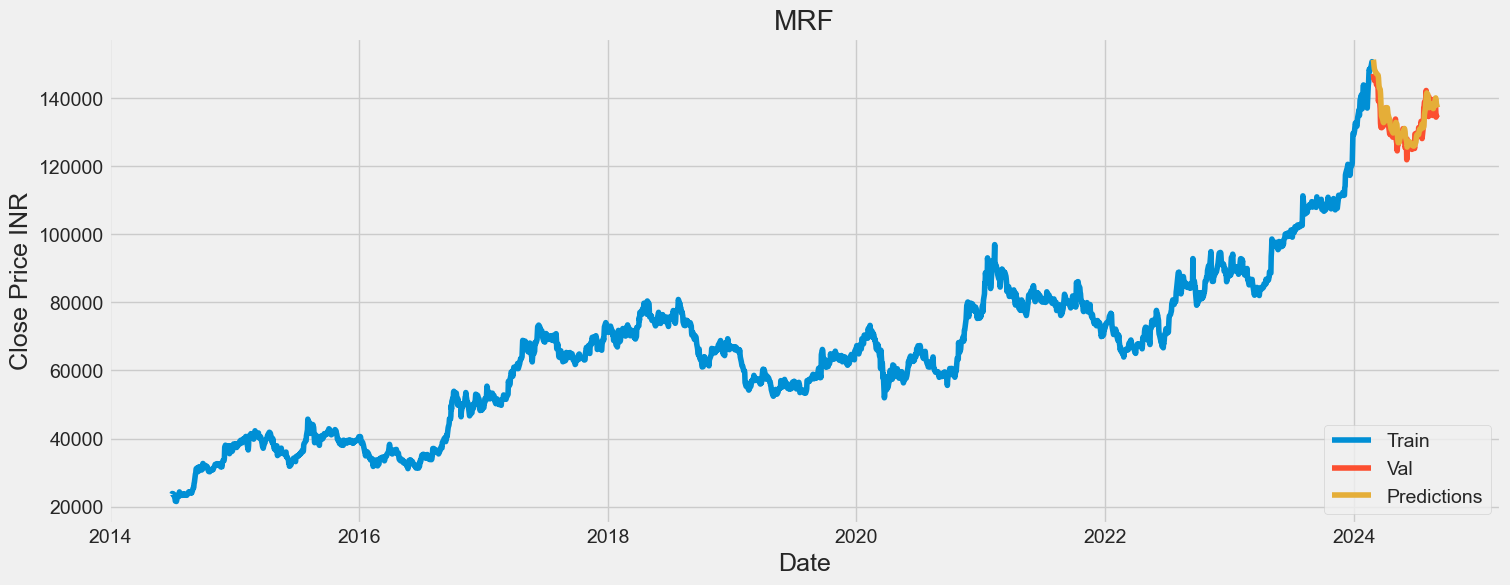

In [29]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('MRF')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [30]:
# Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2024-02-27,147149.156250,151301.484375
2024-02-28,146028.406250,150512.093750
2024-02-29,146081.546875,149440.515625
2024-03-01,145186.000000,148572.156250
2024-03-04,146145.796875,147770.140625
...,...,...
2024-08-27,138807.593750,139776.812500
2024-08-28,136856.296875,140067.312500
2024-08-29,134421.093750,139621.968750


### ARIMA

In [31]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

In [32]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-07-01,23699.800781,23775.000000,23500.000000,23649.750000,23295.550781,2941
2014-07-02,23750.000000,24034.500000,23658.849609,23866.050781,23508.609375,8725
2014-07-03,23875.000000,24049.000000,23550.000000,23732.400391,23376.957031,3469
2014-07-04,23970.000000,23970.000000,23572.599609,23742.449219,23386.855469,3614
2014-07-07,23750.000000,23859.949219,23540.000000,23620.849609,23267.078125,2195
...,...,...,...,...,...,...
2024-08-27,139360.000000,139849.953125,138448.906250,138807.593750,138807.593750,4576
2024-08-28,139500.000000,139500.000000,136486.343750,136856.296875,136856.296875,6441
2024-08-29,137000.000000,137312.843750,133390.000000,134421.093750,134421.093750,10344


In [33]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("The series is stationary")
    else:
        print("The series is not stationary")

adf_test(df['Close'])

ADF Statistic: -0.26284801679384057
p-value: 0.9306038345478299
The series is not stationary


ADF Statistic: -52.95164904326531
p-value: 0.0
The series is stationary


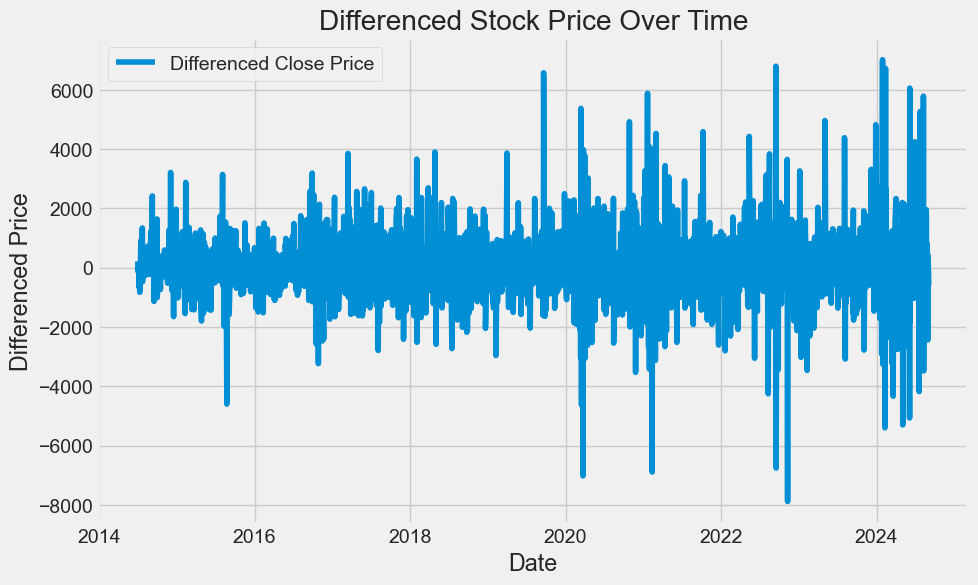

In [34]:
# First differencing
df['Close_diff'] = df['Close'].diff()

# Drop the NaN values
df.dropna(inplace=True)

# Check stationarity again
adf_test(df['Close_diff'])

# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(df['Close_diff'], label='Differenced Close Price')
plt.title('Differenced Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.legend()
plt.show()


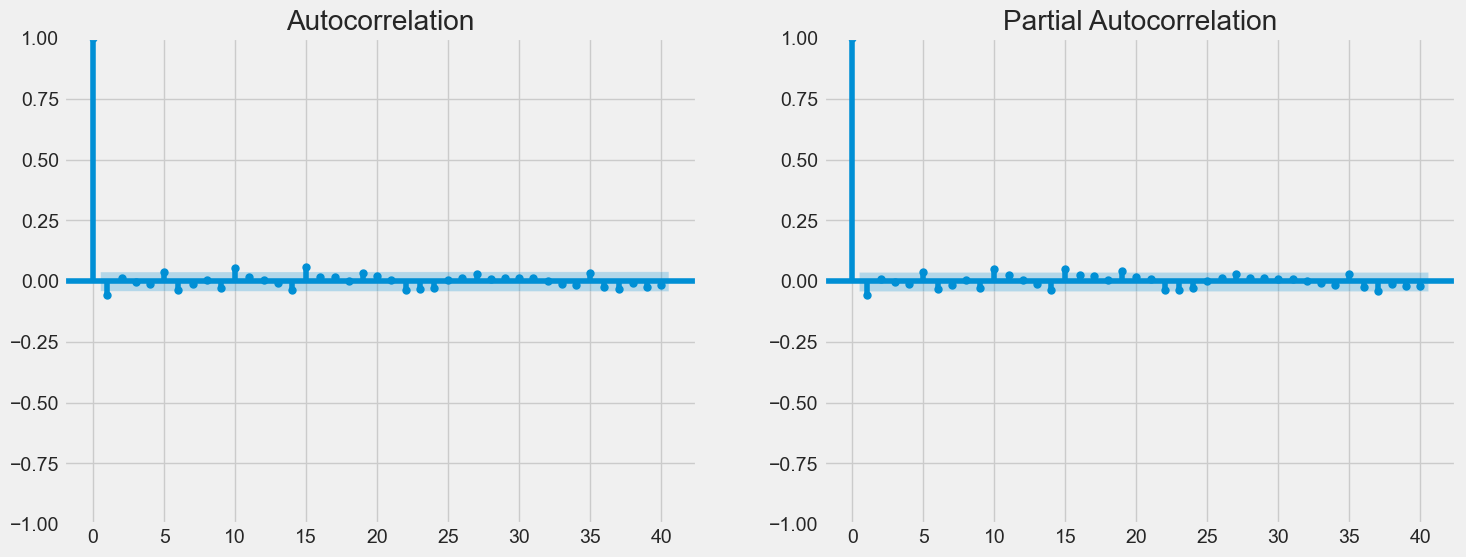

In [35]:
# ACF and PACF plots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sm.graphics.tsa.plot_acf(df['Close_diff'], lags=40, ax=ax[0])
sm.graphics.tsa.plot_pacf(df['Close_diff'], lags=40, ax=ax[1])
plt.show()


In [36]:
# Build the ARIMA model
model = ARIMA(df['Close'], order=(1, 1, 1,))  # Replace p, d, q with the appropriate values
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2505
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -21218.913
Date:                Mon, 02 Sep 2024   AIC                          42443.825
Time:                        15:00:00   BIC                          42461.302
Sample:                             0   HQIC                         42450.170
                               - 2505                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2298      0.281     -0.817      0.414      -0.781       0.322
ma.L1          0.1774      0.283      0.627      0.530      -0.377       0.732
sigma2      1.344e+06   1.96e+04     68.630      0.0

C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


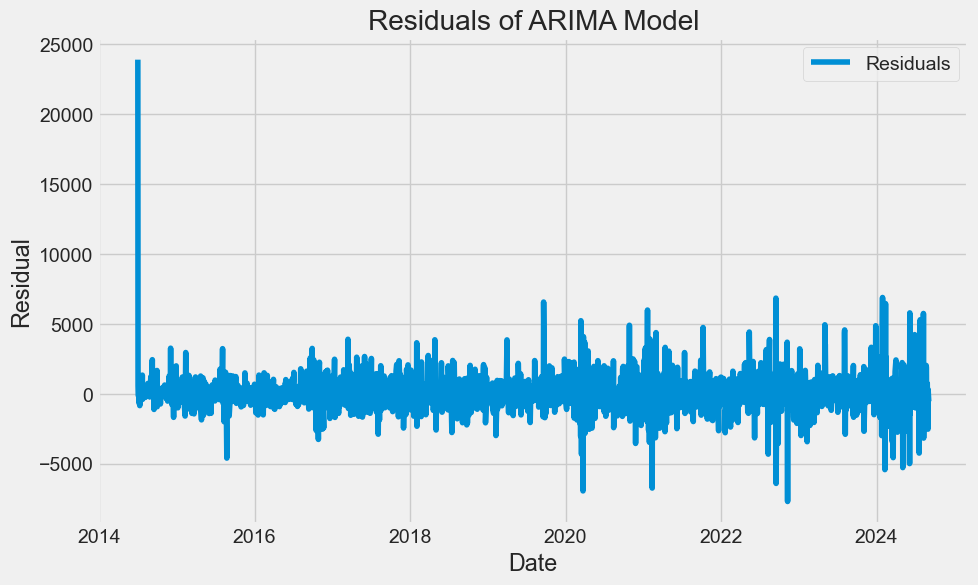

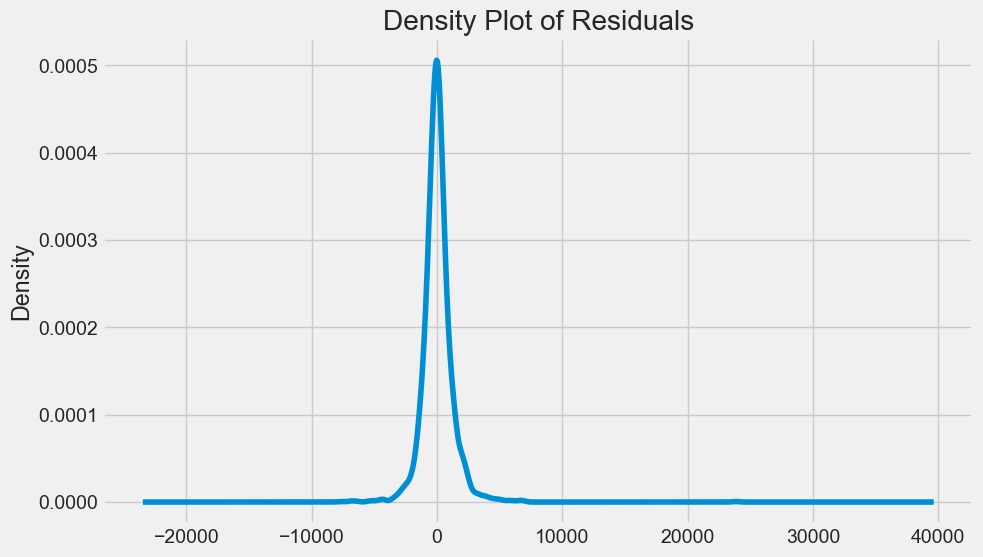

In [37]:
# Plot residuals
residuals = model_fit.resid
plt.figure(figsize=(10, 6))
plt.plot(residuals, label='Residuals')
plt.title('Residuals of ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.show()

# Density plot of residuals
residuals.plot(kind='kde', figsize=(10, 6))
plt.title('Density Plot of Residuals')
plt.show()


In [38]:
# Forecast the next steps
forecast_steps = 30  # Predict the next 30 days
forecast = model_fit.forecast(steps=forecast_steps)

C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [39]:
forecast

2505    134287.789689
2506    134279.096557
2507    134281.093846
2508    134280.634959
2509    134280.740390
2510    134280.716167
2511    134280.721732
2512    134280.720454
2513    134280.720748
2514    134280.720680
2515    134280.720696
2516    134280.720692
2517    134280.720693
2518    134280.720693
2519    134280.720693
2520    134280.720693
2521    134280.720693
2522    134280.720693
2523    134280.720693
2524    134280.720693
2525    134280.720693
2526    134280.720693
2527    134280.720693
2528    134280.720693
2529    134280.720693
2530    134280.720693
2531    134280.720693
2532    134280.720693
2533    134280.720693
2534    134280.720693
Name: predicted_mean, dtype: float64

In [40]:
from sklearn.metrics import mean_squared_error

In [41]:
# Split the data into training and test sets
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

# Build and fit the ARIMA model on training data
model = ARIMA(train, order=(1, 1, 1))  # Replace p, d, q with the appropriate values
model_fit = model.fit()

# Forecast on the test set
forecast_test = model_fit.forecast(steps=len(test))

# Calculate the RMSE
rmse = np.sqrt(mean_squared_error(test, forecast_test))
print(f'RMSE: {rmse}')

C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


RMSE: 29544.550357936332


### SARIMA

In [42]:
from statsmodels.tsa.stattools import adfuller

In [43]:
df

,Open,High,Low,Close,Adj Close,Volume,Close_diff
Date,,,,,,,
2014-07-02,23750.0,24034.500000,23658.849609,23866.050781,23508.609375,8725,216.300781
2014-07-03,23875.0,24049.000000,23550.000000,23732.400391,23376.957031,3469,-133.650391
2014-07-04,23970.0,23970.000000,23572.599609,23742.449219,23386.855469,3614,10.048828
2014-07-07,23750.0,23859.949219,23540.000000,23620.849609,23267.078125,2195,-121.599609
2014-07-08,23750.0,23750.000000,22766.000000,22957.750000,22613.916016,4275,-663.099609
...,...,...,...,...,...,...,...
2024-08-27,139360.0,139849.953125,138448.906250,138807.593750,138807.593750,4576,-516.859375
2024-08-28,139500.0,139500.000000,136486.343750,136856.296875,136856.296875,6441,-1951.296875
2024-08-29,137000.0,137312.843750,133390.000000,134421.093750,134421.093750,10344,-2435.203125


In [44]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("The series is stationary")
    else:
        print("The series is not stationary")

adf_test(df['Close'])


ADF Statistic: -0.26788616221500205
p-value: 0.929931072280453
The series is not stationary


ADF Statistic: -13.78419587099908
p-value: 9.17692509437144e-26
The series is stationary


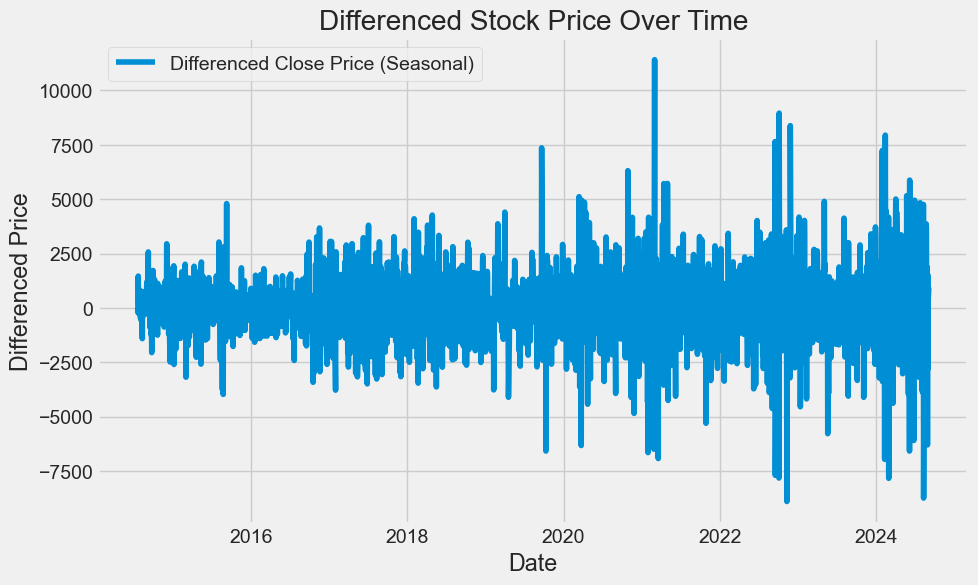

In [45]:
# Apply first differencing
df['Close_diff'] = df['Close'].diff()

# Seasonal differencing
df['Close_diff_seasonal'] = df['Close_diff'].diff(12)  # Assuming monthly data, so seasonal period = 12

# Drop NaN values
df.dropna(inplace=True)

# Check stationarity again
adf_test(df['Close_diff_seasonal'])

# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(df['Close_diff_seasonal'], label='Differenced Close Price (Seasonal)')
plt.title('Differenced Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.legend()
plt.show()


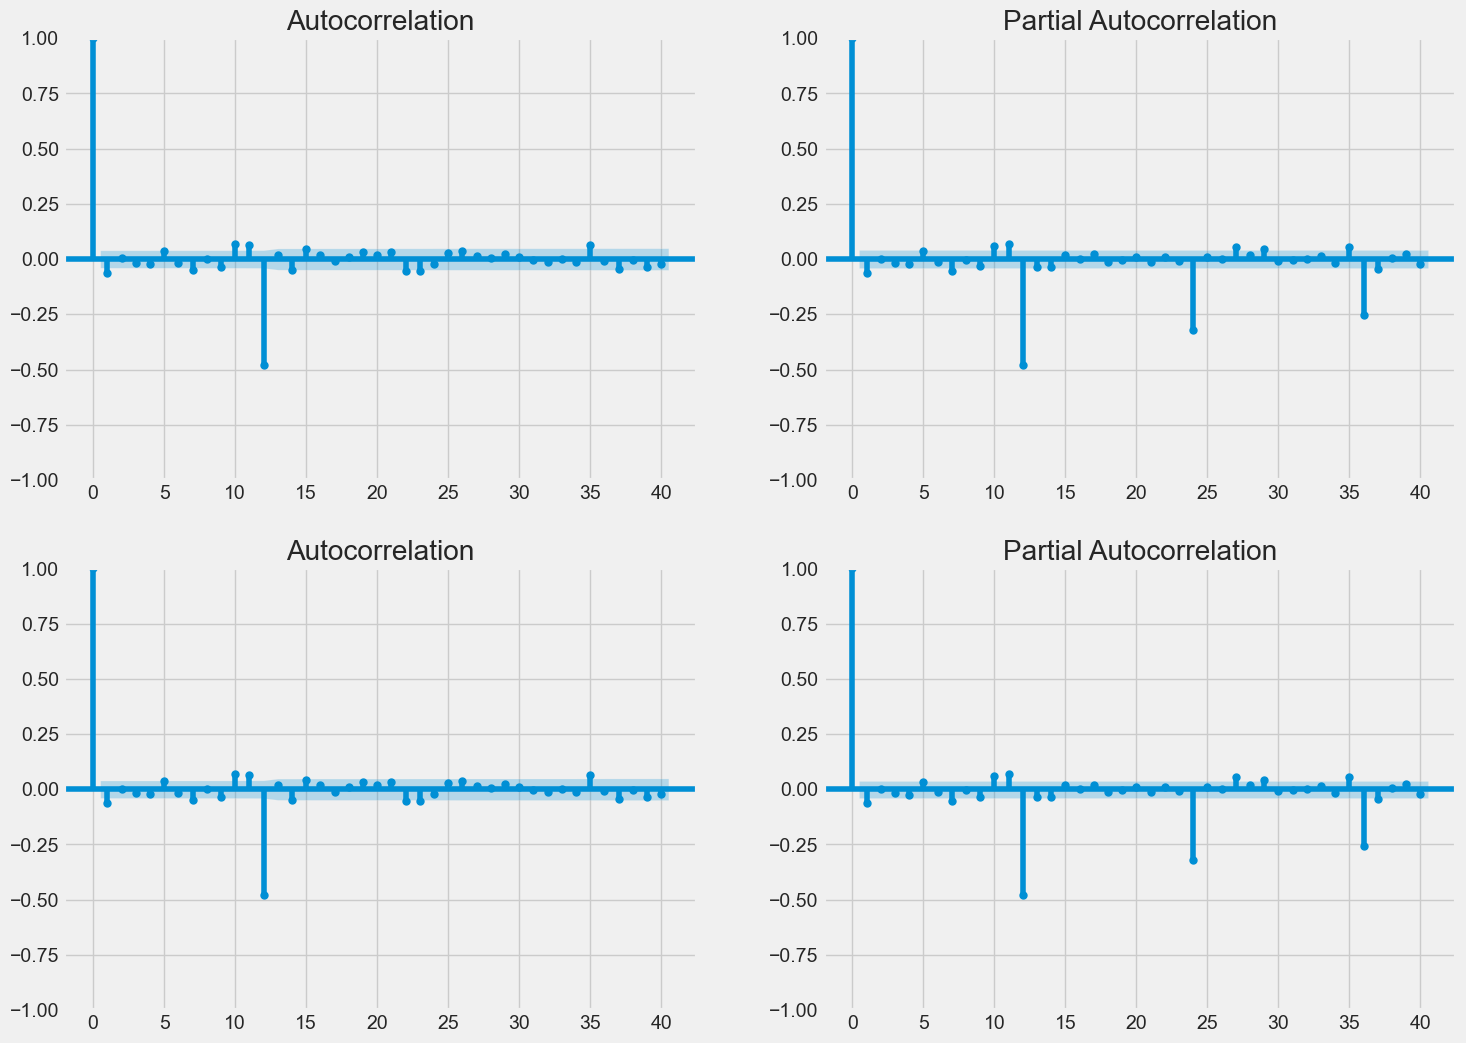

In [46]:
# ACF and PACF plots
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# ACF for differenced series
sm.graphics.tsa.plot_acf(df['Close_diff_seasonal'].dropna(), lags=40, ax=ax[0, 0])
sm.graphics.tsa.plot_pacf(df['Close_diff_seasonal'].dropna(), lags=40, ax=ax[0, 1])

# ACF and PACF for seasonal differencing
sm.graphics.tsa.plot_acf(df['Close_diff_seasonal'].dropna(), lags=40, ax=ax[1, 0])
sm.graphics.tsa.plot_pacf(df['Close_diff_seasonal'].dropna(), lags=40, ax=ax[1, 1])

plt.show()


In [47]:
# Build the SARIMA model
model = sm.tsa.SARIMAX(df['Close'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 2492
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -20941.572
Date:                            Mon, 02 Sep 2024   AIC                          41893.144
Time:                                    15:00:10   BIC                          41922.194
Sample:                                         0   HQIC                         41903.698
                                           - 2492                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2468      0.225     -1.097      0.273      -0.688       0.194
ma.L1          0.1929      0.226   

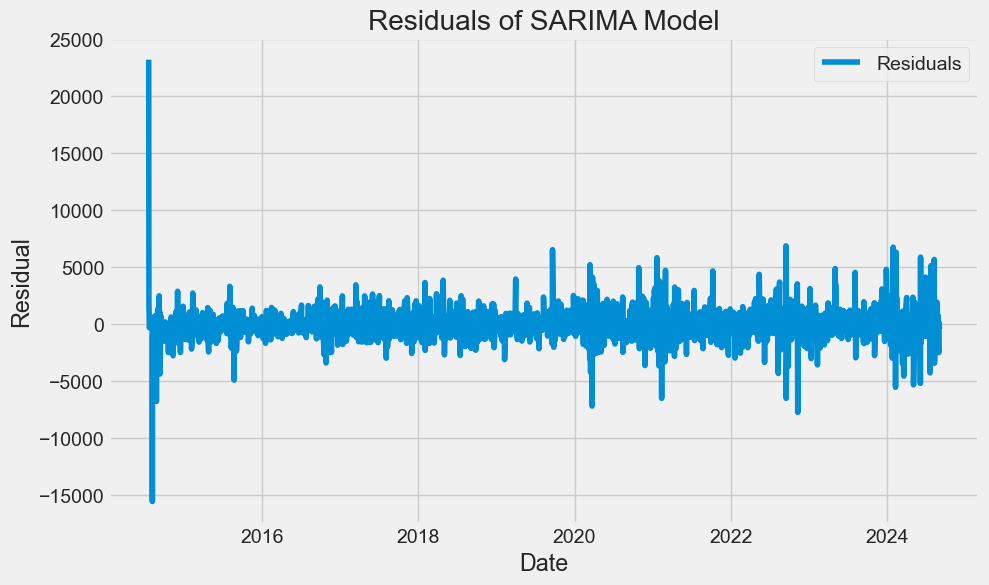

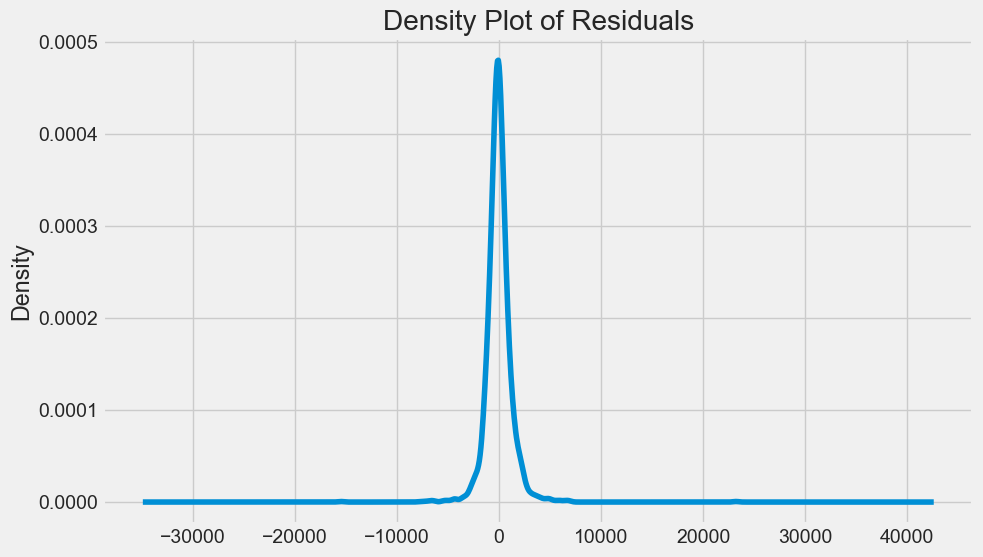

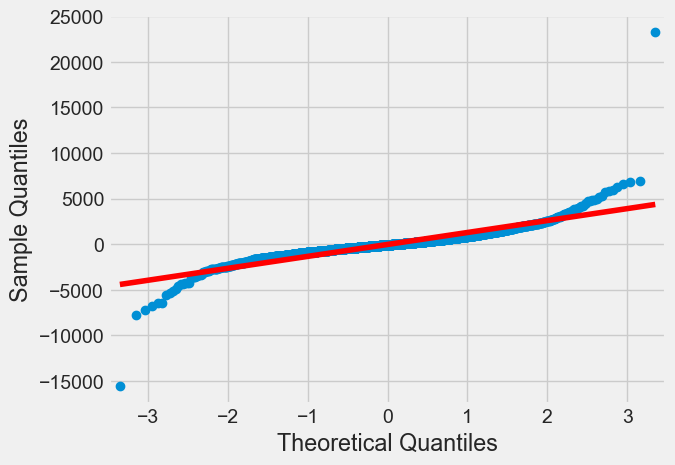

In [48]:
# Plot residuals
residuals = model_fit.resid
plt.figure(figsize=(10, 6))
plt.plot(residuals, label='Residuals')
plt.title('Residuals of SARIMA Model')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.show()

# Density plot of residuals
residuals.plot(kind='kde', figsize=(10, 6))
plt.title('Density Plot of Residuals')
plt.show()

# Check for normality
sm.qqplot(residuals, line='s')
plt.show()


In [49]:
# Forecast the next steps
forecast_steps = 30  # Predict the next 30 days
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(df.index[-1], periods=forecast_steps+1, closed='right')

C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [50]:
# Split the data into training and test sets
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

# Build and fit the SARIMA model on training data
model = sm.tsa.SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit()

# Forecast on the test set
forecast_test = model_fit.get_forecast(steps=len(test))
forecast_test_mean = forecast_test.predicted_mean

# Calculate the RMSE
rmse = np.sqrt(mean_squared_error(test, forecast_test_mean))
print(f'RMSE: {rmse}')

C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE: 22803.76744520916


C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### We select LSTM model as the RMSE score given by the LSTM is lower compare to other models.